---
title: "Integration"
author: "Mary Piper, Meeta Mistry, Radhika Khetani, Jihe Liu, Amelie Jule"
date: Monday, Novemeber 21st, 2020
---

Approximate time: 90 minutes

# Learning Objectives

* Describe the theory of integration with CCA

# Single-cell RNA-seq clustering analysis: Integration theory

<p align="center">
<img src="../img/sc_workflow_2022.jpg" width="630">
</p>

***

_**Goals:**_ 

 - _To **align same cell types** across conditions._

_**Challenges:**_
 
 - _**Aligning cells of similar cell types** so that we do not have clustering downstream due to differences between samples, conditions, modalities, or batches_

_**Recommendations:**_
 
 - _Go through the analysis without integration first to determine whether integration is necessary_

***

In [1]:
# Single-cell RNA-seq - integration

import scanpy as sc
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

adata_filt = sc.read_h5ad("../results/07_normalized.h5ad")

## To integrate or not to integrate?

Generally, we always look at our clustering **without integration** before deciding whether we need to perform any alignment. It can be helpful to first run through clustering with samples from different sample classes together to see whether there are condition-specific clusters for cell types present in both conditions. Oftentimes, when clustering cells from multiple conditions there are condition-specific clusters and integration can help ensure the same cell types cluster together.

 **Do not just always perform integration because you think there might be differences - explore the data.** If we had performed the normalization on both conditions together in a Seurat object and visualized the similarity between cells, we would have seen in our dataset there is condition-specific clustering:


## Example scenarios for integration

- Different **conditions** (e.g. control and stimulated)
	<img src="../img/seurat_condition_integ.png" width="800">

- Different **datasets** (e.g. scRNA-seq from datasets generated using different library preparation methods on the same samples)
	<img src="../img/seurat_dataset_integ.png" width="800">

- Different **modalities** (e.g. scRNA-seq and scATAC-seq)
	<img src="../img/seurat_modality_integ.png" width="800">

- Different **batches** (e.g. when experimental conditions make batch processing of samples necessary)

## Should we integration on our data?
One way to determine if integration is a necessary step is to calculate the UMAP coordinates for the dataset. We will discuss the underlying calculations that are done for each one of these steps in the next lesson.

In [2]:
# Calculate neighbors
sc.pp.neighbors(adata_filt)

# Calculate UMAP
sc.tl.umap(adata_filt)

The best way to assess whether or not there is a clear batch effect is to take a known marker gene and compare it against the batch variable we are concerned with. In this particular case, `sample` is our confounding variable and we can use the T-cell marker `CD3D`. If we see a clear split based upon sample amongst our T cell populations, that is the justification we can use for integration as we are seeing techinical differences that are causing the T-cells to be considered different from one another.

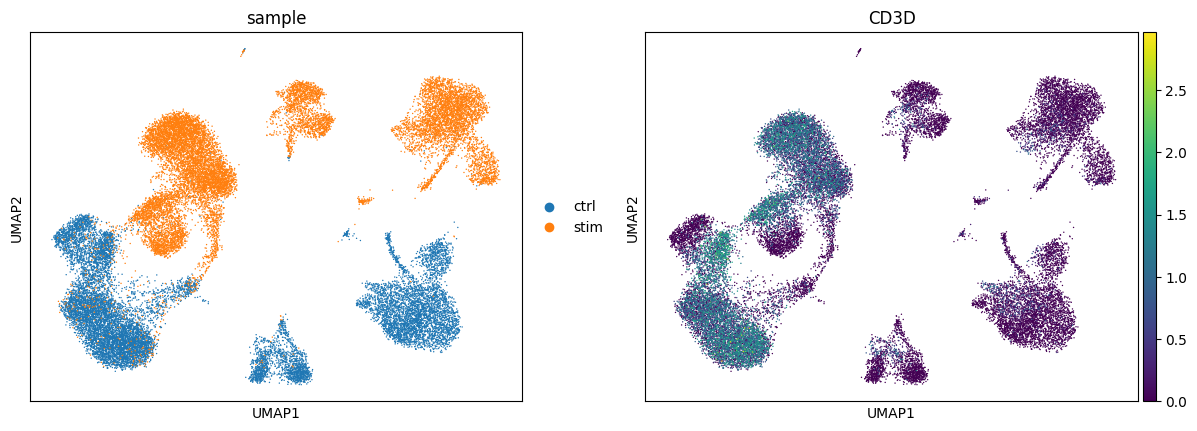

In [4]:
sc.pl.umap(adata_filt, color=["sample", "CD3D"])

Condition-specific clustering of the cells indicates that we need to integrate the cells across conditions to ensure that cells of the same cell type cluster together. 
_**If cells cluster by sample, condition, batch, dataset, modality, performing integration can help align cells across the groups to greatly improve the clustering and the downstream analyses**._

**Why is it important that cells of the same cell type cluster together?** 

We want to identify  _**cell types which are present in all samples/conditions/modalities**_ within our dataset, and therefore would like to observe a representation of cells from both samples/conditions/modalities in every cluster. This will enable more interpretable results downstream (i.e. DE analysis, ligand-receptor analysis, differential abundance analysis...).

# SCVI
TODO: text on what SCVI does - to represent cells and can also do batch correction

In [5]:
import scvi

SCVI makes use of Variational Auto-Encoders in order to construct a model that best fits the data according to the parameters set. We can see the basic informatin about the model before running the train step.

In [6]:
scvi.model.SCVI.setup_anndata(adata_filt, layer="counts", batch_key="sample", 
                              categorical_covariate_keys=["mitoFr"])
model = scvi.model.SCVI(adata_filt, n_layers=2, n_latent=30, gene_likelihood="nb")
model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 30, n_layers: 2, dropout_rate: 0.1, dispersion: gene, gene_likelihood: nb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

::: callout-note
# Epochs
The number of epochs specifies how many iterations of the model training will be done. The more epochs will improve the results of the training. Here we have specific 40 to reduce the amount of time this step takes to run without giving up on the accuracy of the results. By default the number of epochs is typically greater than 200.
:::

In [8]:
# model.train(max_epochs=40)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/nos491/miniconda3/envs/scrna_py/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training:   0%|          | 0/40 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=40` reached.


We use the `get_latent_representation()` function to generate a new latent space (like PCA) that reduces the dimensionality of our dataset while taking into consideration the batch variable we specified earlier. This new latent space, which we store as `X_scvi` can later be used to calculate new neighbors and UMAP coordinates.

In [9]:
# adata_filt.obsm["X_scvi"] = model.get_latent_representation()

adata_filt = sc.read_h5ad("../results/08_integration.h5ad")
adata_filt

AnnData object with n_obs × n_vars = 29629 × 14167
    obs: 'n_genes', 'sample', 'n_genes_by_counts', 'total_counts', 'log10GenesPerUMI', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'mito_ratio', 'S_score', 'G2M_score', 'phase', 'mitoFr', '_scvi_batch', '_scvi_labels'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mito', 'log1p_mean_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'id_hvg', 'log1p', 'mitoFr_colors', 'pca', 'phase_colors', 'sample_colors', 'neighbors', 'umap', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', '_scvi_extra_categorical_covs', 'X_scvi'
    varm: 'PCs'
    layers: 'c

Now we can compare and contrast the latent representation that was calculated with PCA and the new SCVI representation. This allows us to see what batch correction has been accomplished.

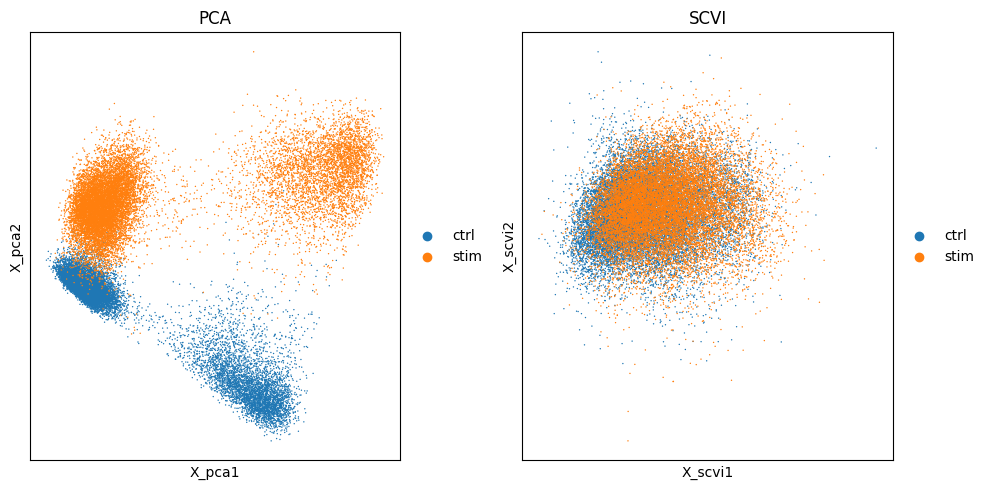

In [13]:
# Create plot with the correct dimensions
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sc.pl.embedding(adata_filt, basis='X_pca', color='sample',
               ax=axes[0], title="PCA", show=False)
sc.pl.embedding(adata_filt, basis='X_scvi', color='sample',
               ax=axes[1], title="SCVI", show=False)

plt.tight_layout()
plt.show()

# Save

In [15]:
# adata_filt.write_h5ad("../results/08_integration.h5ad")